In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:



# Load parquet files
benign_df = pd.read_csv("processedData/benign.csv")
mal_df = pd.read_csv("processedData/malware_binary.csv")

print("Benign shape:", benign_df.shape)
print("Malware shape:", mal_df.shape)
 
# IMPORTANT: reset column names to be identical
benign_df.columns = range(benign_df.shape[1])
mal_df.columns = range(mal_df.shape[1])


# Concatenate safely
df = pd.concat([benign_df, mal_df], axis=0, ignore_index=True)

print("Final dataset shape:", df.shape)
#print(df["label"].value_counts())

print(df.shape)


#colomn 9505 is ur lable

Benign shape: (162181, 9505)
Malware shape: (195624, 9505)
Final dataset shape: (357805, 9505)
(357805, 9505)


In [3]:


X = df.drop(9504, axis=1).select_dtypes(include=[np.number])  # also drop hash column (1)
y = df[9504]

# Compute correlation of each feature with label
correlations = X.corrwith(y)

# Sort by absolute correlation
corr_sorted = correlations.abs().sort_values(ascending=False)

print(corr_sorted.head(20))

/home/gentlsnek/MajorProject/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/gentlsnek/MajorProject/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


50      0.747576
57      0.716959
37      0.699974
48      0.699124
58      0.683630
36      0.683147
3052    0.682764
63      0.682764
3335    0.640379
51      0.639820
66      0.634830
107     0.626421
25      0.626364
3293    0.595365
35      0.591604
26      0.583790
39      0.564001
9       0.529084
138     0.521460
8       0.510686
dtype: float64


In [4]:
TOP_N = 20

top_features = corr_sorted.head(TOP_N).index.tolist()

print("Selected feature indices:", top_features)

Selected feature indices: [50, 57, 37, 48, 58, 36, 3052, 63, 3335, 51, 66, 107, 25, 3293, 35, 26, 39, 9, 138, 8]


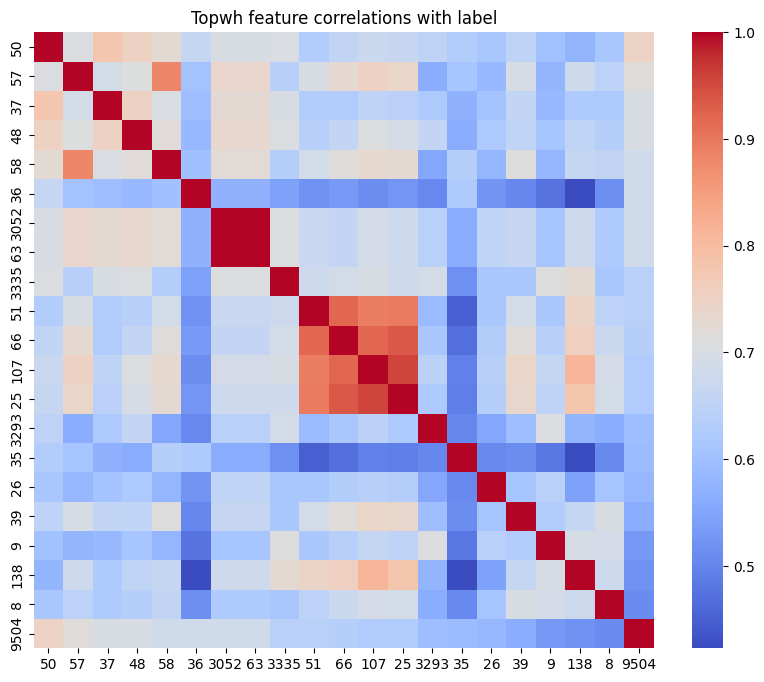

In [9]:


top20 = corr_sorted.head(20).index
corr_matrix = df[top_features + [9504]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Topwh feature correlations with label")
plt.show()

In [10]:
X_reduced = X[top_features]

In [11]:
print(X.iloc[:,0].head())

0     52
1     71
2    688
3    295
4    319
Name: 1, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2,random_state=42
)

model = RandomForestClassifier(
    n_estimators=200, n_jobs=-1, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", model.score(X_test, y_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9628009670071687
Confusion Matrix:
 [[31595   952]
 [ 1710 37304]]
Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96     32547
           1       0.98      0.96      0.97     39014

    accuracy                           0.96     71561
   macro avg       0.96      0.96      0.96     71561
weighted avg       0.96      0.96      0.96     71561



In [13]:
import numpy as np

y_train_shuffled = np.random.permutation(y_train)
model.fit(X_train, y_train_shuffled)
print("Accuracy with shuffled labels:", model.score(X_test, y_test))

Accuracy with shuffled labels: 0.5625969452634815


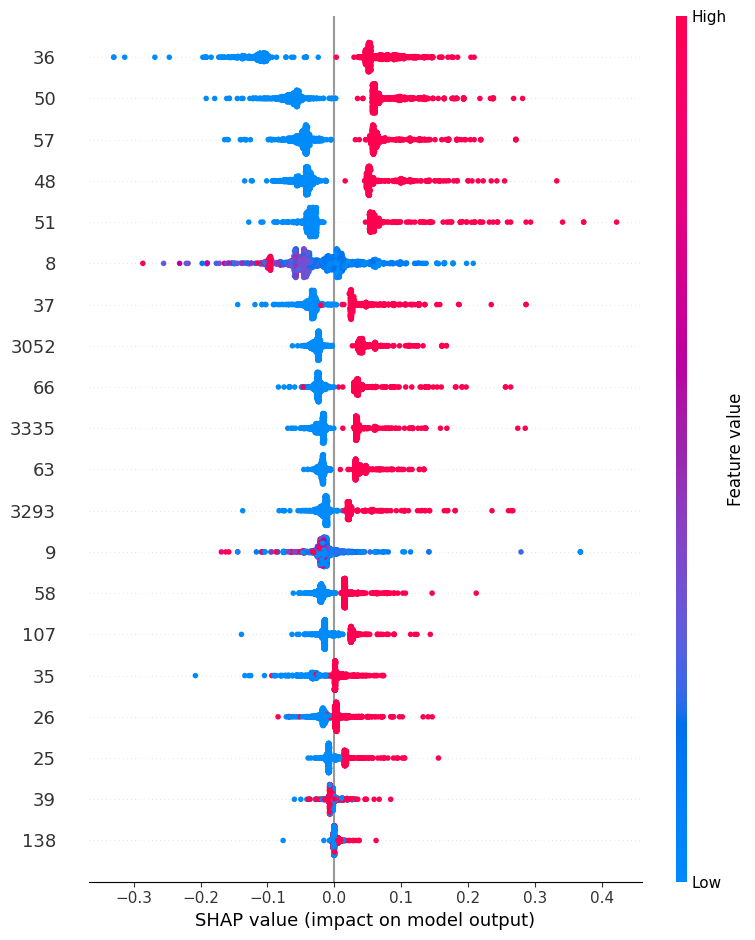

In [18]:

import shap
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# sample only 200 rows
X_sample = X_train.sample(1000)

# train a smaller RF just for SHAP
rf_shap = RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_shap.fit(X_train, y_train)

explainer = shap.TreeExplainer(rf_shap)


shap_values = explainer(X_sample)  # only malware class
malicious_shap_values = shap_values [:, :, 1]

shap.summary_plot(malicious_shap_values, X_sample)


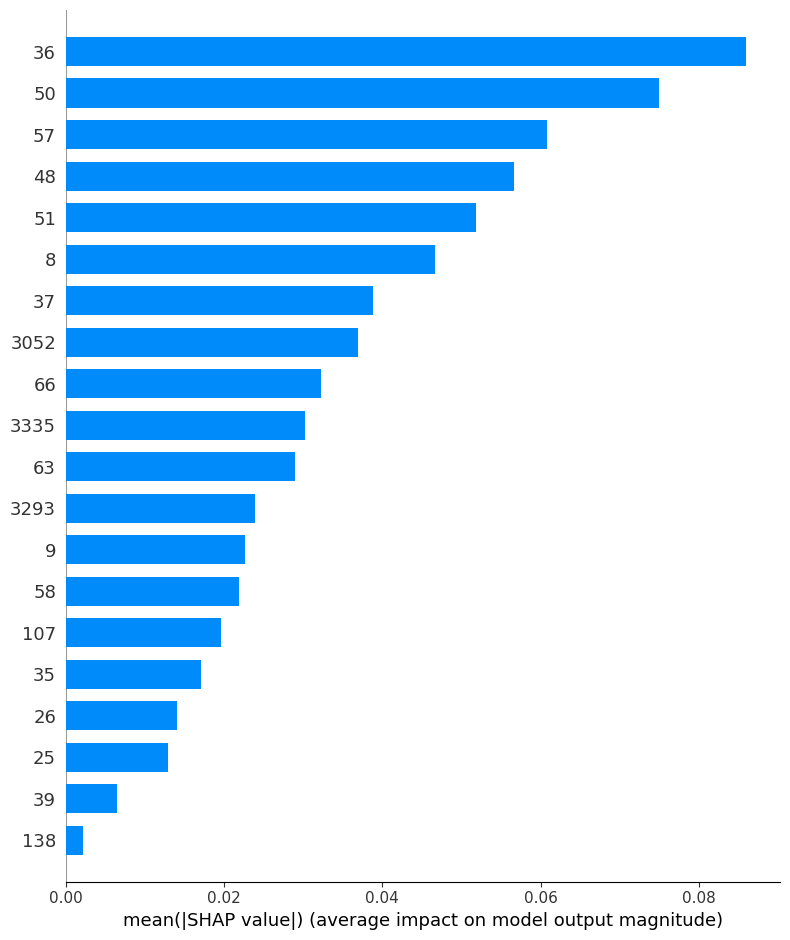

In [19]:
shap.summary_plot(shap_values[:, :, 1], X_sample, plot_type="bar")

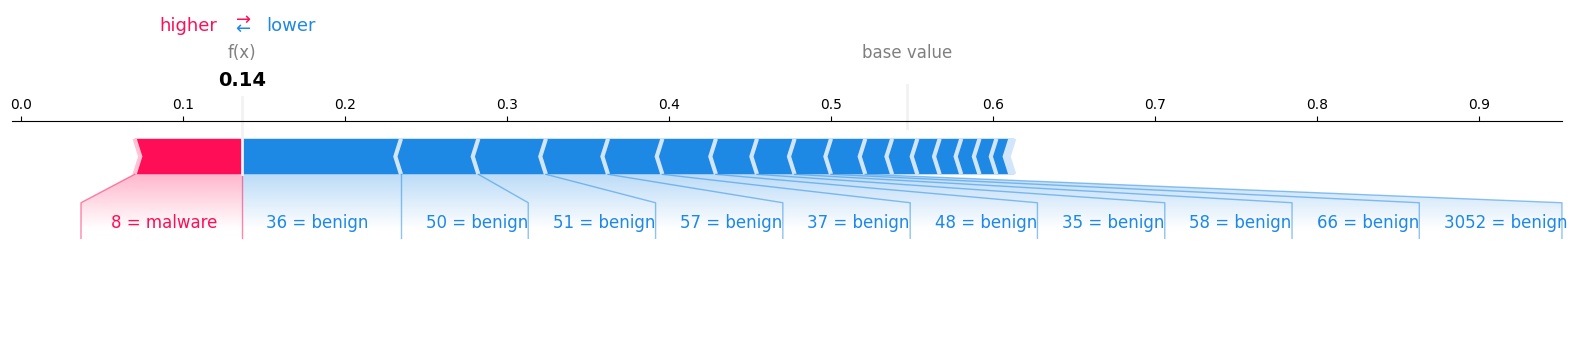

In [20]:
i = 0  # The index of the Android app you want to explain
feature_values = X_sample.iloc[i, :].map(lambda x: 'malware' if x == 1 else 'benign')
# Use .values to get the specific array for the plot
shap.force_plot(
    explainer.expected_value[1],     # The base value for 'Malicious'
    shap_values.values[i, :, 1],    # Add .values here to pass the raw array
    feature_values,        # The actual feature values
    matplotlib=True
)

In [22]:
sample = X_test.iloc[0:70]
pred = model.predict(sample)
# 2. Iterate through the predictions

explainer = shap.TreeExplainer(model)
shap_explanations = explainer(sample, check_additivity=False)

for i, app_pred in enumerate(pred):
    status = "Malware" if app_pred == 1 else "Benign"
    
    # Get the SHAP values for this specific app (class 1: Malicious)
    # We look for the highest positive contributions for Malware
    # and highest negative contributions for Benign
    current_shap_values = shap_explanations.values[i, :, 1]
    feature_names = sample.columns
    
    # Sort features by their impact (absolute SHAP value)
    top_indices = np.argsort(np.abs(current_shap_values))[-3:][::-1]
    
    reasons = []
    for idx in top_indices:
        val = current_shap_values[idx]
        feature_name = feature_names[idx]
        direction = "contributed to Malware risk" if val > 0 else "suggested Benign behavior"
        reasons.append(f"{feature_name} ({direction} risk by {abs(val):.4f})%")
        

    print(f"App {i}: {status} detected.")
    print(f"   Reasoning: {', '.join(reasons)}\n")

App 0: Malware detected.
   Reasoning: 3293 (suggested Benign behavior risk by 0.0205)%, 9 (contributed to Malware risk risk by 0.0199)%, 138 (contributed to Malware risk risk by 0.0088)%

App 1: Malware detected.
   Reasoning: 35 (suggested Benign behavior risk by 0.0073)%, 58 (suggested Benign behavior risk by 0.0032)%, 8 (contributed to Malware risk risk by 0.0028)%

App 2: Malware detected.
   Reasoning: 3293 (suggested Benign behavior risk by 0.0205)%, 9 (contributed to Malware risk risk by 0.0199)%, 138 (contributed to Malware risk risk by 0.0088)%

App 3: Malware detected.
   Reasoning: 37 (contributed to Malware risk risk by 0.0169)%, 57 (contributed to Malware risk risk by 0.0155)%, 36 (suggested Benign behavior risk by 0.0113)%

App 4: Malware detected.
   Reasoning: 35 (contributed to Malware risk risk by 0.0315)%, 36 (contributed to Malware risk risk by 0.0127)%, 8 (contributed to Malware risk risk by 0.0124)%

App 5: Malware detected.
   Reasoning: 58 (contributed to Malwa